In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("feature_engineered_netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,content_length_category
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Long
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Long
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Long
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Long
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Long


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   show_id                  8807 non-null   str  
 1   type                     8807 non-null   str  
 2   title                    8807 non-null   str  
 3   director                 8807 non-null   str  
 4   cast                     8807 non-null   str  
 5   country                  8807 non-null   str  
 6   date_added               8709 non-null   str  
 7   release_year             8807 non-null   int64
 8   rating                   8807 non-null   str  
 9   duration                 8807 non-null   str  
 10  listed_in                8807 non-null   str  
 11  description              8807 non-null   str  
 12  content_length_category  8807 non-null   str  
dtypes: int64(1), str(12)
memory usage: 894.6 KB


In [4]:
df.isnull().sum()

show_id                     0
type                        0
title                       0
director                    0
cast                        0
country                     0
date_added                 98
release_year                0
rating                      0
duration                    0
listed_in                   0
description                 0
content_length_category     0
dtype: int64

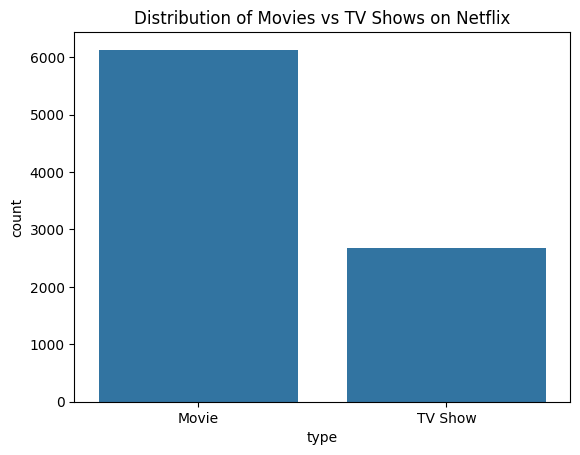

In [5]:
sns.countplot(x="type", data=df)
plt.title("Distribution of Movies vs TV Shows on Netflix")
plt.show()

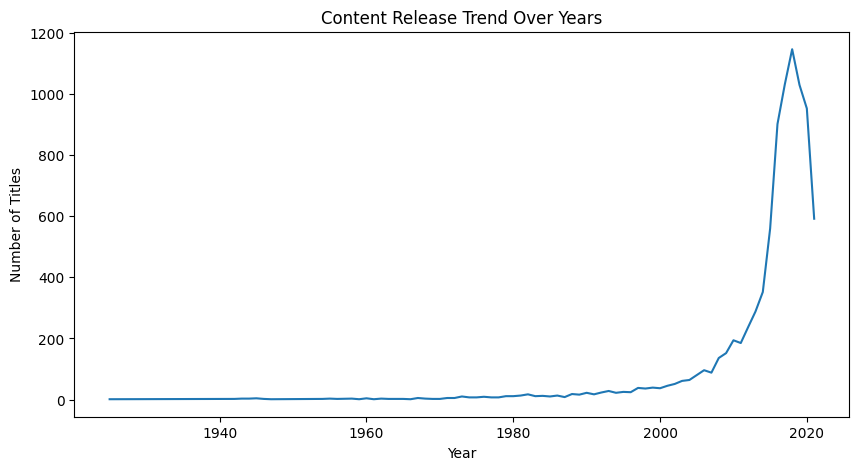

In [6]:
plt.figure(figsize=(10,5))
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

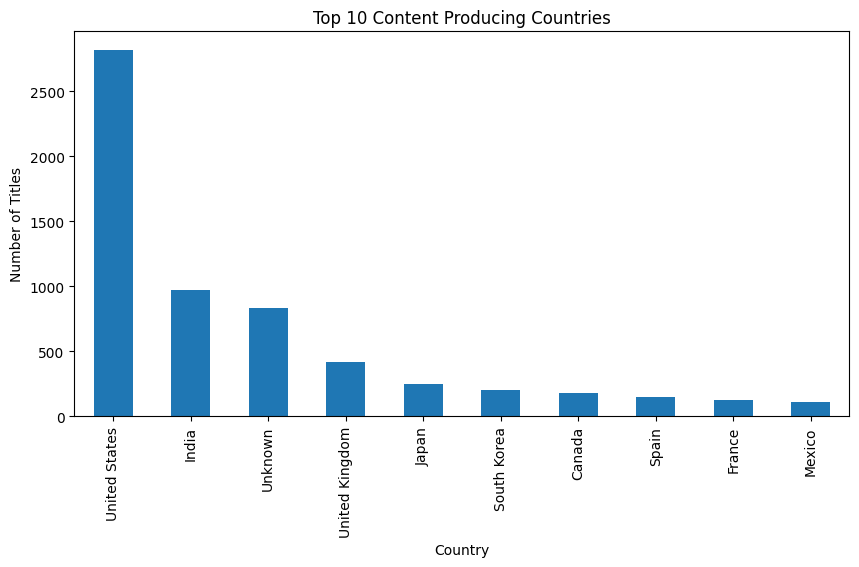

In [7]:
plt.figure(figsize=(10,5))
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

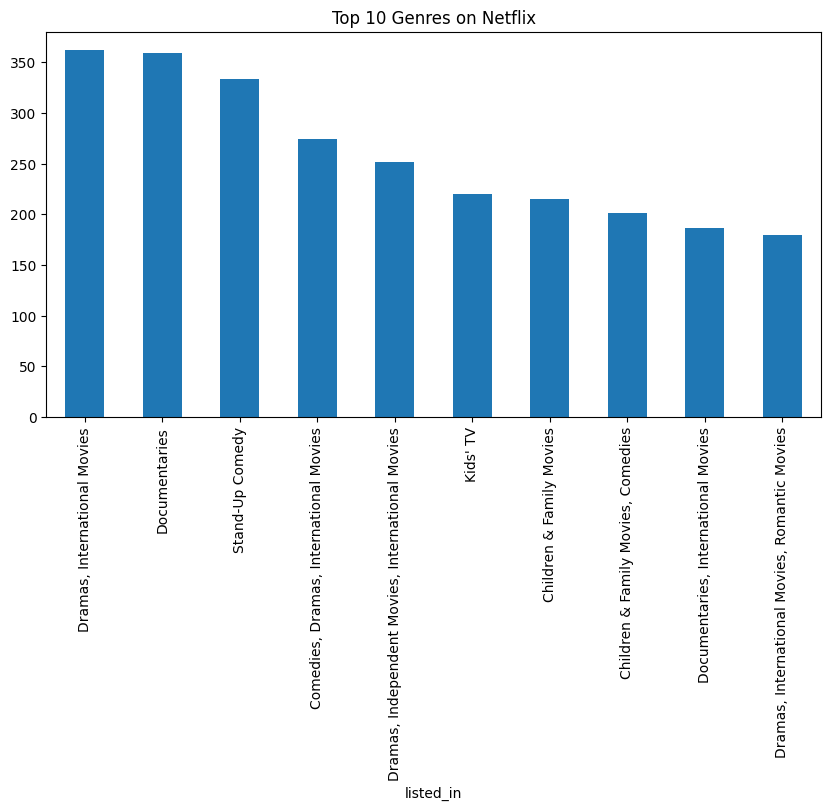

In [8]:
plt.figure(figsize=(10,5))
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.show()

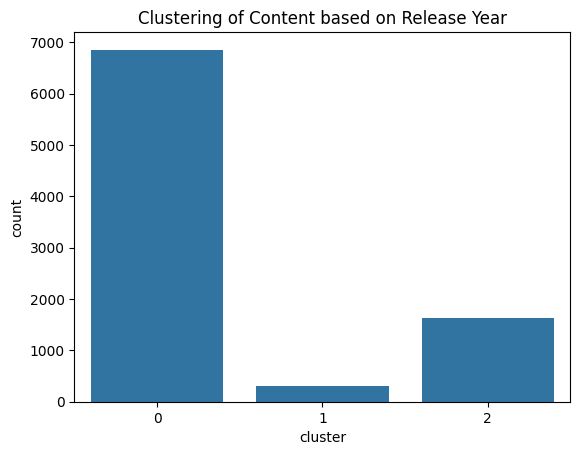

In [9]:
from sklearn.cluster import KMeans

# Use numeric columns
X = df[['release_year']].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

sns.countplot(x='cluster', data=df)
plt.title("Clustering of Content based on Release Year")
plt.show()

In [12]:
X = df[['release_year', 'duration']].dropna()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df[['release_year']].dropna()
y = df['type'].loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6935300794551645
